# Logistic Regression: 
### Sigmoid, Binary Cross Entropy Loss, Gradient Derivation, Decision Boundary PLot


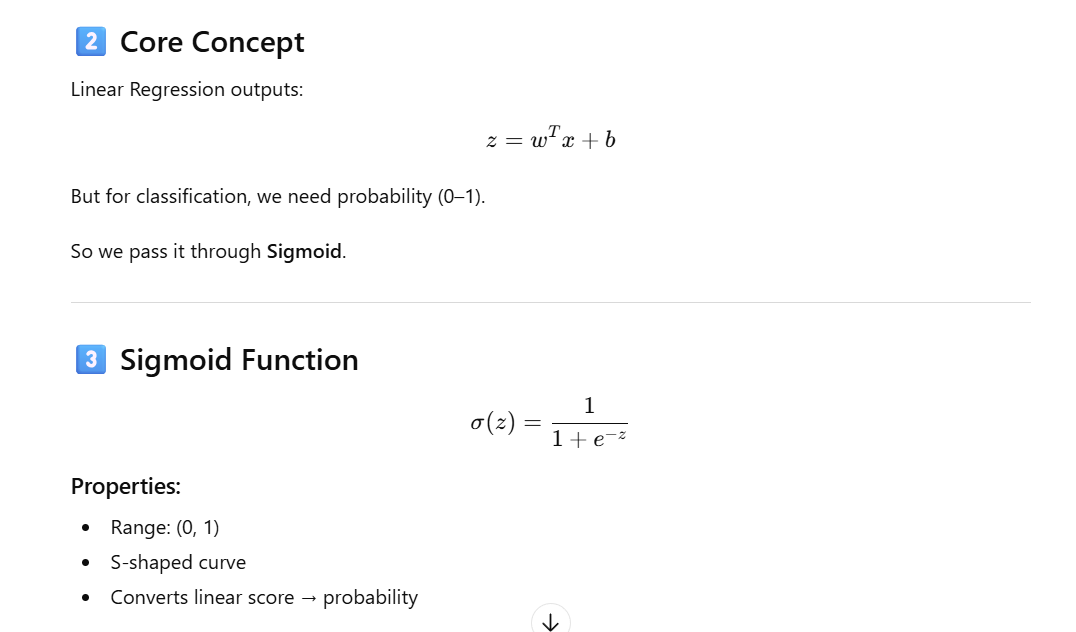

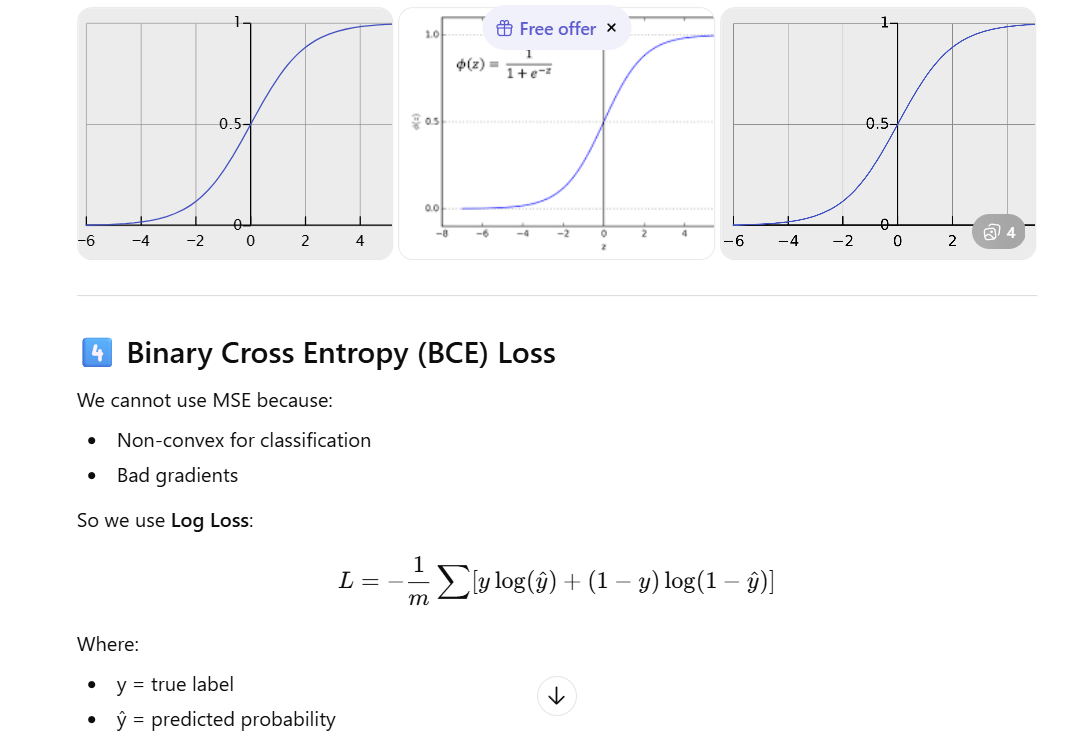

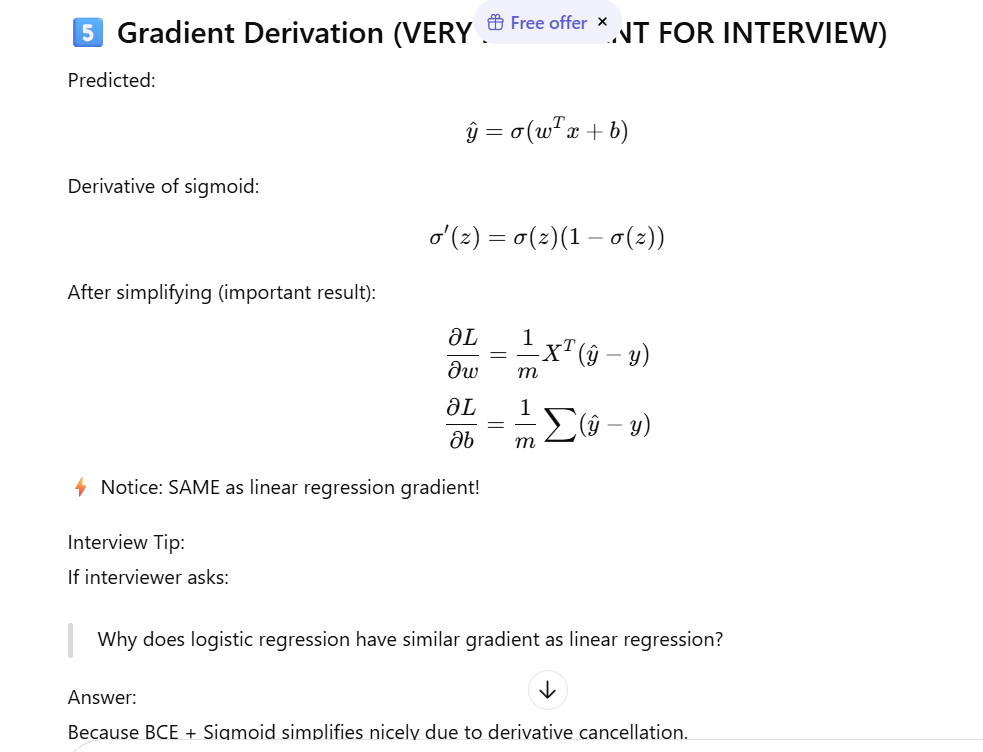

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generate synthetic data

np.random.seed(42)

class0 = np.random.randn(100, 2) + np.array([-2, -2])
class1 = np.random.randn(100, 2) + np.array([2, 2])

X = np.vstack((class0, class1))
y = np.hstack((np.zeros(100), np.ones(100)))

In [3]:
# Logistic Regession Class

class LogisticRegression:

    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    # Sigmoid
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    # Binary Cross Entropy Loss
    def compute_loss(self, y, y_hat):
        m = len(y)
        epsilon = 1e-8 #prevent Log(0)
        loss = -(1/m) * np.sum(
            y * np.log(y_hat + epsilon) + (1-y) * np.log(1-y_hat + epsilon)
        )
        return loss
    
    # Training using gradient descent
    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        self.losses = []

        for i in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_hat = self.sigmoid(z)

            # Gradients
            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)

            # Update
            self.w -= self.lr * dw
            self.b -= self.lr * db 

            # Store Loss
            loss = self.compute_loss(y, y_hat)
            self.losses.append(loss)

        return self
    
    # Predict probability
    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        return self.sigmoid(z)
    
    # Predict class
    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)


In [4]:
# Train Model
model = LogisticRegression(lr=0.1, epochs=1000)
model.fit(X, y)

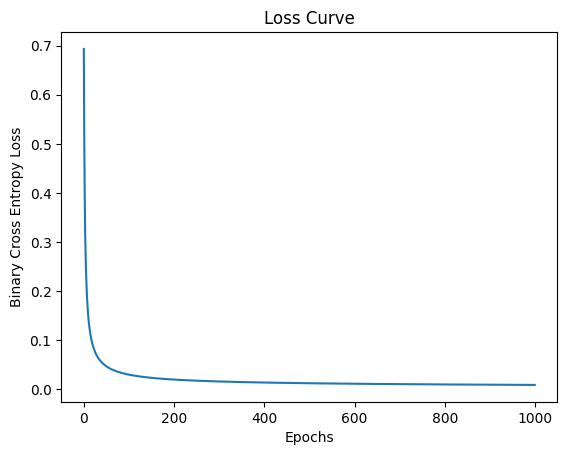

In [5]:
# Plot Loss Curve
plt.figure()
plt.plot(model.losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.show()

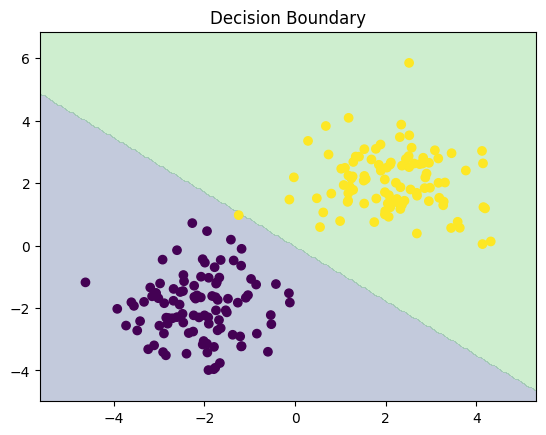

In [6]:
# Plot Decision Boundary

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)
    Z = probs.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z >= 0.5, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("Decision Boundary")
    plt.show()


plot_decision_boundary(model, X, y)